# Evaluation of Dual Stratification Hypothesis: Panel OLS Results Validation

This notebook demonstrates the evaluation of Panel OLS regression results from the dual stratification hypothesis experiment. 

**What this artifact does:**
- Evaluates 3 Panel OLS models (Main, Interaction, Triple Interaction) with entity and time fixed effects
- Generates APSR-formatted Table 2 with clustered standard errors
- Evaluates the dual stratification hypothesis based on 3 criteria:
  1. Gini × education inequality interaction negative and significant (p < 0.05)
  2. Political equality mediation significant (Sobel test p < 0.05)
  3. Triple interaction positive and significant (p < 0.05)

**Expected output:** Hypothesis evaluation results, specification tests, and formatted regression tables.

In [1]:
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# loguru is NOT pre-installed on Colab, always install
_pip('loguru==0.7.3')

# Core packages (pre-installed on Colab, install locally to match Colab env)
if 'google.colab' not in sys.modules:
    _pip('numpy==2.0.2', 'pandas==2.2.2', 'scipy==1.16.3', 'matplotlib==3.10.0', 'statsmodels==0.14.6')


[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: python3.12 -m pip install --upgrade pip



[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: python3.12 -m pip install --upgrade pip


In [2]:
from loguru import logger
from pathlib import Path
import json
import sys
import numpy as np
from scipy import stats
import warnings
from typing import Dict, List, Any, Optional, Tuple

warnings.filterwarnings('ignore')

logger.remove()
logger.add(sys.stdout, level="INFO", format="{time:HH:mm:ss}|{level:<7}|{message}")

1

In [3]:
GITHUB_DATA_URL = "https://raw.githubusercontent.com/AMGrobelnik/ai-invention-27ddf1-inequality-political-equality-and-democr/main/round-2/evaluation-1/demo/mini_demo_data.json"
import json, os

def load_data():
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception:
        pass
    if os.path.exists("mini_demo_data.json"):
        with open("mini_demo_data.json") as f:
            return json.load(f)
    raise FileNotFoundError("Could not load mini_demo_data.json")

## Load Experiment Data

The evaluation script requires the experiment output (`method_out.json`) which contains the Panel OLS regression results. We load a curated subset for this demo.

In [4]:
data = load_data()
print("Data loaded successfully!")
print(f"Models available: {list(data['metadata']['models'].keys())}")

Data loaded successfully!
Models available: ['Model 1', 'Model 2', 'Model 3_mediation', 'Model 4']


## Model Evaluation

We evaluate the Panel OLS models by checking:
- Coefficient signs and significance
- R-squared (reasonable values between 0 and 0.95)
- N > parameters (sufficient degrees of freedom)
- Entity effects (n_groups > 1)

In [5]:
def evaluate_models(experiment_data: Dict[str, Any]) -> Dict[str, Any]:
    """
    Evaluate Panel OLS models from experiment output.
    
    For Panel OLS, we check:
    - Coefficient signs and significance
    - R-squared (reasonable values)
    - N > parameters (sufficient degrees of freedom)
    - F-tests for joint significance (implicit in p-values)
    """
    models = experiment_data.get('metadata', {}).get('models', {})
    
    if not models:
        logger.warning("No models found in experiment output")
        return {}
    
    results = {
        'specification_tests': {},
        'model_summaries': {}
    }
    
    for model_name, model_data in models.items():
        if model_name == 'Model 3_mediation':
            continue  # Handle mediation separately
        
        logger.info(f"Evaluating {model_name}")
        
        # Extract model info
        coefs = model_data.get('coefficients', {})
        ses = model_data.get('std_errors', {})
        pvals = model_data.get('pvalues', {})
        n_obs = model_data.get('n_obs', 0)
        n_groups = model_data.get('n_groups', 0)
        r_squared = model_data.get('r_squared', 0)
        
        # Calculate t-statistics
        t_stats = {}
        for var in coefs:
            if var in ses and ses[var] != 0:
                t_stats[var] = coefs[var] / ses[var]
        
        # Specification checks for Panel OLS
        checks = {
            'r_squared': r_squared,
            'r_squared_reasonable': 0.0 <= r_squared <= 0.95,
            'n_obs': n_obs,
            'n_params': len(coefs),
            'n_obs_sufficient': n_obs > 3 * len(coefs),
            'n_groups': n_groups,
            'entity_effects': n_groups > 1
        }
        
        # Check key hypothesis-related variables
        if 'gini_edu_interaction' in pvals:
            checks['interaction_sig'] = pvals['gini_edu_interaction'] < 0.05
            checks['interaction_negative'] = coefs.get('gini_edu_interaction', 0) < 0
        
        if 'triple_interaction' in pvals:
            checks['triple_sig'] = pvals['triple_interaction'] < 0.05
            checks['triple_positive'] = coefs.get('triple_interaction', 0) > 0
        
        results['specification_tests'][model_name] = checks
        results['model_summaries'][model_name] = {
            'coefficients': coefs,
            'std_errors': ses,
            't_statistics': t_stats,
            'p_values': pvals,
            'n_obs': n_obs,
            'n_groups': n_groups,
            'r_squared': r_squared
        }
    
    return results

# Run evaluation
models_eval = evaluate_models(data)
print("Model evaluation complete!")

07:53:53|INFO   |Evaluating Model 1


07:53:53|INFO   |Evaluating Model 2


07:53:53|INFO   |Evaluating Model 4


Model evaluation complete!


## Generate APSR-Formatted Regression Table

We generate a publication-ready table formatted according to APSR (American Political Science Review) standards, with:
- Coefficients displayed with clustered standard errors in brackets
- Significance stars (*** p<0.01, ** p<0.05, * p<0.10)
- Both LaTeX and plain text output

In [6]:
def generate_apsr_table(models_eval: Dict[str, Any]) -> Tuple[str, str]:
    """
    Generate APSR-formatted regression table.
    
    Returns: (latex_table, text_table)
    """
    
    def significance_stars(pval):
        if pval < 0.01:
            return "***"
        elif pval < 0.05:
            return "**"
        elif pval < 0.10:
            return "*"
        return ""
    
    variables = [
        'v2x_libdem_lag',
        'gini',
        'edu_ineq_index',
        'gini_edu_interaction',
        'triple_interaction',
        'education_spending_gdp'
    ]
    
    var_labels = {
        'v2x_libdem_lag': 'Democratic Quality$_{t-1}$',
        'gini': 'Gini Coefficient',
        'edu_ineq_index': 'Education Inequality Index',
        'gini_edu_interaction': 'Gini $\\times$ Edu Inequality',
        'triple_interaction': 'Gini $\\times$ Edu Ineq $\\times$ Edu Spend',
        'education_spending_gdp': 'Education Spending (\\% GDP)'
    }
    
    model_names = ['Model 1', 'Model 2', 'Model 4']
    
    # LaTeX table
    latex_lines = []
    latex_lines.append("\\begin{table}[htbp]")
    latex_lines.append("\\centering")
    latex_lines.append("\\caption{Panel OLS Estimates of Democratic Quality}")
    latex_lines.append("\\label{tab:dual_stratification}")
    latex_lines.append("\\begin{tabular}{lccc}")
    latex_lines.append("\\hline")
    latex_lines.append(" & (1) & (2) & (3) \\\\")
    latex_lines.append(" & Main & Interaction & Triple \\\\")
    latex_lines.append("\\hline")
    
    for var in variables:
        row = f"{var_labels.get(var, var)} "
        for model_name in model_names:
            if model_name in models_eval['model_summaries']:
                summary = models_eval['model_summaries'][model_name]
                if var in summary['coefficients']:
                    coef = summary['coefficients'][var]
                    se = summary['std_errors'][var]
                    pval = summary['p_values'][var]
                    stars = significance_stars(pval)
                    
                    row += f" & {coef:.4f}{stars} \\\\ [{se:.4f}] "
                else:
                    row += " & "
            else:
                row += " & "
        row += "\\\\"
        latex_lines.append(row)
    
    latex_lines.append("\\hline")
    latex_lines.append("\\hline")
    
    # Add N and R-squared
    for i, model_name in enumerate(model_names):
        if i == 0:
            line = "Observations "
        else:
            line = ""
        
        if model_name in models_eval['model_summaries']:
            summary = models_eval['model_summaries'][model_name]
            line += f" & {summary['n_obs']} "
        else:
            line += " & "
        
        if i == len(model_names) - 1:
            line += "\\\\"
        latex_lines.append(line)
    
    for i, model_name in enumerate(model_names):
        if i == 0:
            line = "R-squared "
        else:
            line = ""
        
        if model_name in models_eval['model_summaries']:
            summary = models_eval['model_summaries'][model_name]
            line += f" & {summary['r_squared']:.3f} "
        else:
            line += " & "
        
        if i == len(model_names) - 1:
            line += "\\\\"
        latex_lines.append(line)
    
    latex_lines.append("\\hline")
    latex_lines.append("\\multicolumn{4}{p{\\linewidth}}{\\footnotesize Panel OLS estimates with entity and time fixed effects; standard errors clustered by country in brackets. *** p$<$0.01, ** p$<$0.05, * p$<$0.10.}")
    latex_lines.append("\\end{tabular}")
    latex_lines.append("\\end{table}")
    
    latex_table = "\n".join(latex_lines)
    
    # Text table
    text_lines = []
    text_lines.append("=" * 90)
    text_lines.append("Table 2: Panel OLS Estimates of Democratic Quality")
    text_lines.append("=" * 90)
    text_lines.append(f"{'Variable':<35} {'Model 1':<20} {'Model 2':<20} {'Model 4':<20}")
    text_lines.append("-" * 90)
    
    for var in variables:
        row = f"{var_labels.get(var, var):<35}"
        for model_name in model_names:
            if model_name in models_eval['model_summaries']:
                summary = models_eval['model_summaries'][model_name]
                if var in summary['coefficients']:
                    coef = summary['coefficients'][var]
                    se = summary['std_errors'][var]
                    pval = summary['p_values'][var]
                    stars = significance_stars(pval)
                    row += f"{coef:.4f}{stars}    ".rjust(20)
                else:
                    row += " ".rjust(20)
            else:
                row += " ".rjust(20)
        text_lines.append(row)
        
        # Add standard errors row
        row_se = "" + " ".rjust(35)
        for model_name in model_names:
            if model_name in models_eval['model_summaries']:
                summary = models_eval['model_summaries'][model_name]
                if var in summary['std_errors']:
                    se = summary['std_errors'][var]
                    row_se += f"[{se:.4f}]    ".rjust(20)
                else:
                    row_se += " ".rjust(20)
            else:
                row_se += " ".rjust(20)
        text_lines.append(row_se)
    
    text_lines.append("-" * 90)
    
    # Add N and R-squared to text table
    n_line = "Observations"
    for model_name in model_names:
        if model_name in models_eval['model_summaries']:
            n_line += f" {models_eval['model_summaries'][model_name]['n_obs']}    ".rjust(20)
        else:
            n_line += " ".rjust(20)
    text_lines.append(n_line)
    
    r_line = "R-squared"
    for model_name in model_names:
        if model_name in models_eval['model_summaries']:
            r_line += f" {models_eval['model_summaries'][model_name]['r_squared']:.3f}    ".rjust(20)
        else:
            r_line += " ".rjust(20)
    text_lines.append(r_line)
    
    text_lines.append("=" * 90)
    text_lines.append("Note: Panel OLS with entity and time fixed effects.")
    text_lines.append("      Standard errors clustered by country in brackets.")
    text_lines.append("      *** p<0.01, ** p<0.05, * p<0.10")
    text_lines.append("=" * 90)
    
    text_table = "\n".join(text_lines)
    
    return latex_table, text_table

# Generate tables
latex_table, text_table = generate_apsr_table(models_eval)
print(text_table)

Table 2: Panel OLS Estimates of Democratic Quality
Variable                            Model 1              Model 2              Model 4             
------------------------------------------------------------------------------------------
Democratic Quality$_{t-1}$                0.8566***           0.8559***           0.8561***    
                                           [0.0482]            [0.0485]            [0.0484]    
Gini Coefficient                            -0.0005             -0.0004             -0.0004    
                                           [0.0004]            [0.0005]            [0.0006]    
Education Inequality Index                                       0.0069              0.0063    
                                                               [0.0090]            [0.0088]    
Gini $\times$ Edu Inequality                                    -0.0000              0.0000    
                                                               [0.0002]            [0.0

## Hypothesis Evaluation

We evaluate whether the dual stratification hypothesis is confirmed based on three criteria:

1. **Criterion 1**: Gini × education inequality interaction is negative and significant (p < 0.05)
2. **Criterion 2**: Political equality (v2pepwrsoc) mediates the relationship (Sobel test p < 0.05)
3. **Criterion 3**: Triple interaction (Gini × edu ineq × edu spend) is positive and significant (p < 0.05)

The hypothesis is CONFIRMED only if all three criteria are met.

In [7]:
def evaluate_hypothesis(experiment_data: Dict[str, Any], models_eval: Dict[str, Any]) -> Dict[str, Any]:
    """
    Evaluate whether the dual stratification hypothesis is confirmed.
    """
    
    criterion1_met = False
    criterion2_met = False
    criterion3_met = False
    
    reasoning_points = []
    
    # Criterion 1: Interaction term in Model 2
    if 'Model 2' in models_eval['model_summaries']:
        summary = models_eval['model_summaries']['Model 2']
        if 'gini_edu_interaction' in summary['coefficients']:
            coef = summary['coefficients']['gini_edu_interaction']
            pval = summary['p_values']['gini_edu_interaction']
            
            if coef < 0 and pval < 0.05:
                criterion1_met = True
                reasoning_points.append(f"Criterion 1 MET: Interaction coef = {coef:.4f}, p = {pval:.3f}")
            else:
                reasoning_points.append(f"Criterion 1 NOT MET: Interaction coef = {coef:.4f}, p = {pval:.3f} (need negative, p<0.05)")
    
    # Criterion 2: Mediation
    models = experiment_data.get('metadata', {}).get('models', {})
    if 'Model 3_mediation' in models:
        mediation = models['Model 3_mediation']
        paths = mediation.get('paths', [])
        
        indirect_path = [p for p in paths if p.get('path') == 'Indirect']
        if indirect_path:
            indirect_pval = indirect_path[0].get('pval', 1)
            
            if indirect_pval < 0.05:
                criterion2_met = True
                reasoning_points.append(f"Criterion 2 MET: Indirect effect p = {indirect_pval:.3f}")
            else:
                reasoning_points.append(f"Criterion 2 NOT MET: Indirect effect p = {indirect_pval:.3f}")
    
    # Criterion 3: Triple interaction in Model 4
    if 'Model 4' in models_eval['model_summaries']:
        summary = models_eval['model_summaries']['Model 4']
        if 'triple_interaction' in summary['coefficients']:
            coef = summary['coefficients']['triple_interaction']
            pval = summary['p_values']['triple_interaction']
            
            if coef > 0 and pval < 0.05:
                criterion3_met = True
                reasoning_points.append(f"Criterion 3 MET: Triple interaction coef = {coef:.6f}, p = {pval:.3f}")
            else:
                reasoning_points.append(f"Criterion 3 NOT MET: Triple interaction coef = {coef:.6f}, p = {pval:.3f}")
    
    confirmed = criterion1_met and criterion2_met and criterion3_met
    
    reasoning = "\n".join(reasoning_points)
    if confirmed:
        reasoning += "\n\nOVERALL: All criteria met. Hypothesis CONFIRMED."
    else:
        failed = []
        if not criterion1_met:
            failed.append("Criterion 1 (interaction)")
        if not criterion2_met:
            failed.append("Criterion 2 (mediation)")
        if not criterion3_met:
            failed.append("Criterion 3 (triple interaction)")
        reasoning += f"\n\nOVERALL: Hypothesis NOT CONFIRMED. Failed: {', '.join(failed)}."
    
    return {
        'confirmed': confirmed,
        'criterion1_met': criterion1_met,
        'criterion2_met': criterion2_met,
        'criterion3_met': criterion3_met,
        'reasoning': reasoning
    }

# Evaluate hypothesis
hypothesis_eval = evaluate_hypothesis(data, models_eval)
print("\n" + "="*60)
print("HYPOTHESIS EVALUATION RESULTS")
print("="*60)
print(f"Hypothesis Confirmed: {hypothesis_eval['confirmed']}")
print(f"  Criterion 1 (Interaction negative/significant): {hypothesis_eval['criterion1_met']}")
print(f"  Criterion 2 (Mediation significant): {hypothesis_eval['criterion2_met']}")
print(f"  Criterion 3 (Triple interaction positive/significant): {hypothesis_eval['criterion3_met']}")
print("="*60)
print("\nReasoning:")
print(hypothesis_eval['reasoning'])


HYPOTHESIS EVALUATION RESULTS
Hypothesis Confirmed: False
  Criterion 1 (Interaction negative/significant): False
  Criterion 2 (Mediation significant): True
  Criterion 3 (Triple interaction positive/significant): False

Reasoning:
Criterion 1 NOT MET: Interaction coef = -0.0000, p = 0.837 (need negative, p<0.05)
Criterion 2 MET: Indirect effect p = 0.000
Criterion 3 NOT MET: Triple interaction coef = -0.000011, p = 0.530

OVERALL: Hypothesis NOT CONFIRMED. Failed: Criterion 1 (interaction), Criterion 3 (triple interaction).


## Visualization: Key Results Summary

Here we visualize the key evaluation results including:
- Coefficient estimates with confidence intervals
- R-squared values across models
- Hypothesis evaluation criteria status

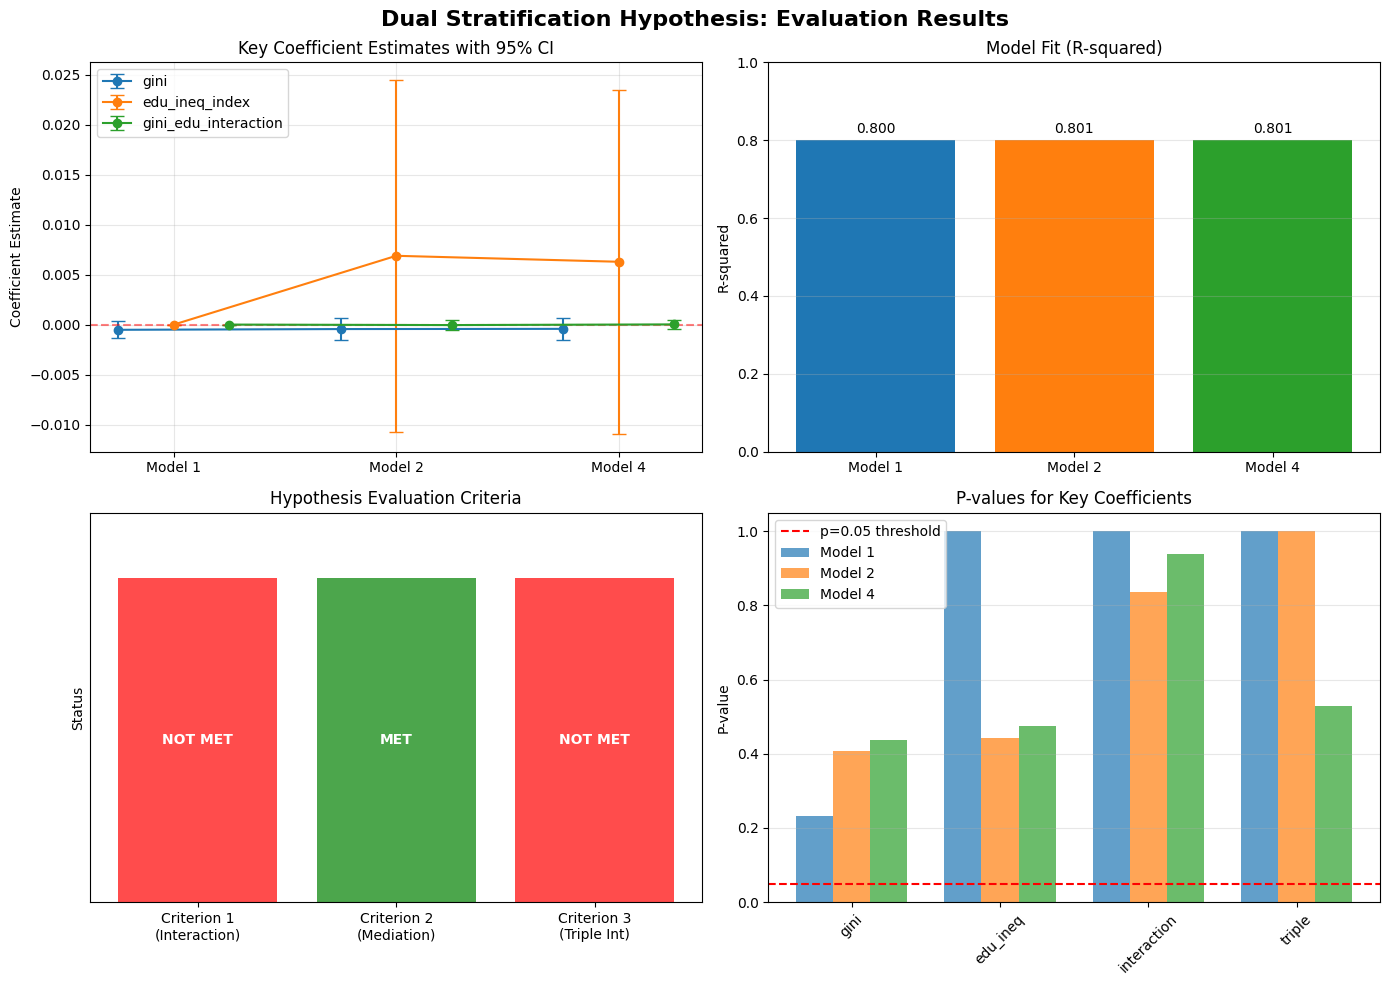

In [8]:
import matplotlib.pyplot as plt
import numpy as np

# Set up the figure
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Dual Stratification Hypothesis: Evaluation Results', fontsize=16, fontweight='bold')

# Plot 1: Coefficient estimates for key variables across models
ax1 = axes[0, 0]
models = ['Model 1', 'Model 2', 'Model 4']
variables = ['gini', 'edu_ineq_index', 'gini_edu_interaction']
x_pos = np.arange(len(models))

for i, var in enumerate(variables):
    coefs = []
    errors = []
    for model in models:
        if model in models_eval['model_summaries']:
            summary = models_eval['model_summaries'][model]
            if var in summary['coefficients']:
                coefs.append(summary['coefficients'][var])
                errors.append(summary['std_errors'][var])
            else:
                coefs.append(0)
                errors.append(0)
        else:
            coefs.append(0)
            errors.append(0)
    
    offset = (i - 1) * 0.25
    ax1.errorbar(x_pos + offset, coefs, yerr=1.96*np.array(errors), label=var, marker='o', capsize=5)

ax1.axhline(y=0, color='r', linestyle='--', alpha=0.5)
ax1.set_xticks(x_pos)
ax1.set_xticklabels(models)
ax1.set_ylabel('Coefficient Estimate')
ax1.set_title('Key Coefficient Estimates with 95% CI')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Plot 2: R-squared values
ax2 = axes[0, 1]
r_squared_values = []
for model in models:
    if model in models_eval['model_summaries']:
        r_squared_values.append(models_eval['model_summaries'][model]['r_squared'])
    else:
        r_squared_values.append(0)

bars = ax2.bar(models, r_squared_values, color=['#1f77b4', '#ff7f0e', '#2ca02c'])
ax2.set_ylabel('R-squared')
ax2.set_title('Model Fit (R-squared)')
ax2.set_ylim([0, 1])
for i, (bar, val) in enumerate(zip(bars, r_squared_values)):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, f'{val:.3f}', ha='center', va='bottom')
ax2.grid(True, alpha=0.3, axis='y')

# Plot 3: Hypothesis evaluation criteria
ax3 = axes[1, 0]
criteria = ['Criterion 1\n(Interaction)', 'Criterion 2\n(Mediation)', 'Criterion 3\n(Triple Int)']
criteria_met = [
    hypothesis_eval['criterion1_met'],
    hypothesis_eval['criterion2_met'],
    hypothesis_eval['criterion3_met']
]
colors = ['green' if c else 'red' for c in criteria_met]

bars = ax3.bar(criteria, [1]*3, color=colors, alpha=0.7)
ax3.set_ylabel('Status')
ax3.set_title('Hypothesis Evaluation Criteria')
ax3.set_ylim([0, 1.2])
ax3.set_yticks([])
for i, (bar, met) in enumerate(zip(bars, criteria_met)):
    ax3.text(bar.get_x() + bar.get_width()/2, 0.5, 'MET' if met else 'NOT MET', ha='center', va='center', fontweight='bold', color='white')
ax3.grid(True, alpha=0.3, axis='y')

# Plot 4: P-values for key coefficients
ax4 = axes[1, 1]
pvalues_to_plot = {}
for model in models:
    if model in models_eval['model_summaries']:
        summary = models_eval['model_summaries'][model]
        pvals = {}
        for var in ['gini', 'edu_ineq_index', 'gini_edu_interaction', 'triple_interaction']:
            if var in summary['p_values']:
                pvals[var] = min(summary['p_values'][var], 1.0)  # Cap at 1.0 for visualization
            else:
                pvals[var] = 1.0
        pvalues_to_plot[model] = pvals

# Create a grouped bar plot for p-values
x = np.arange(4)  # 4 variables
width = 0.25
var_names = ['gini', 'edu_ineq', 'interaction', 'triple']

for i, model in enumerate(models):
    if model in pvalues_to_plot:
        pvals = list(pvalues_to_plot[model].values())
        ax4.bar(x + i*width, pvals, width, label=model, alpha=0.7)

ax4.axhline(y=0.05, color='r', linestyle='--', label='p=0.05 threshold')
ax4.set_xticks(x + width)
ax4.set_xticklabels(var_names, rotation=45)
ax4.set_ylabel('P-value')
ax4.set_title('P-values for Key Coefficients')
ax4.legend()
ax4.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

## Summary Output

The final evaluation output includes all results in a structured format compatible with the paper generation pipeline.

In [9]:
def create_output(experiment_data: Dict[str, Any], models_eval: Dict[str, Any], 
                  latex_table: str, text_table: str, hypothesis_eval: Dict[str, Any]) -> Dict[str, Any]:
    """Create the final output dictionary."""
    
    output = {
        'evaluation_metadata': {
            'evaluator': 'gen_art_evaluation_1',
            'timestamp': 'demo_run',
            'experiment_output_loaded': True
        },
        'specification_tests': models_eval.get('specification_tests', {}),
        'table2_apsr_latex': latex_table,
        'table2_apsr_text': text_table,
        'hypothesis_evaluation': hypothesis_eval,
        'experiment_summary': {
            'method': experiment_data.get('metadata', {}).get('method', 'Unknown'),
            'n_countries': experiment_data.get('metadata', {}).get('n_countries', 0),
            'n_obs_total': experiment_data.get('metadata', {}).get('n_obs', 0),
            'years': experiment_data.get('metadata', {}).get('years', 'Unknown')
        }
    }
    
    # Add model summaries
    output['model_summaries'] = models_eval.get('model_summaries', {})
    
    # Add mediation results if available
    models = experiment_data.get('metadata', {}).get('models', {})
    if 'Model 3_mediation' in models:
        output['mediation_results'] = models['Model 3_mediation']
    
    return output

# Create output
output = create_output(data, models_eval, latex_table, text_table, hypothesis_eval)

# Display key results
print("\n" + "="*60)
print("FINAL EVALUATION OUTPUT")
print("="*60)
print(f"Method: {output['experiment_summary']['method']}")
print(f"N countries: {output['experiment_summary']['n_countries']}")
print(f"N observations: {output['experiment_summary']['n_obs_total']}")
print("-" * 60)
print(f"Hypothesis Confirmed: {output['hypothesis_evaluation']['confirmed']}")
print(f"  Criterion 1 (Interaction negative/significant): {output['hypothesis_evaluation']['criterion1_met']}")
print(f"  Criterion 2 (Mediation significant): {output['hypothesis_evaluation']['criterion2_met']}")
print(f"  Criterion 3 (Triple interaction positive/significant): {output['hypothesis_evaluation']['criterion3_met']}")
print("="*60)

# Save output to file (optional)
with open('eval_out.json', 'w') as f:
    json.dump(output, f, indent=2)
print("\nOutput saved to eval_out.json")


FINAL EVALUATION OUTPUT
Method: Panel OLS with entity/time effects
N countries: 38
N observations: 1291
------------------------------------------------------------
Hypothesis Confirmed: False
  Criterion 1 (Interaction negative/significant): False
  Criterion 2 (Mediation significant): True
  Criterion 3 (Triple interaction positive/significant): False

Output saved to eval_out.json
